<a href="https://colab.research.google.com/github/diegofloriano/Deteccao-fraudes-transacoes-DIO/blob/main/Deteccao_fraudes_transacoes_DIO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Detecção de fraudes e transações

In [ ]:
import pandas as pd

url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"

df = pd.read_csv(url)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# Problema de classificação desbalanceada

fraudes são raras, o modelo pode ignorar a classe 1(fraude) e aprender errado


In [ ]:
df["Class"].value_counts(normalize=True)

,proportion
Class,
0,0.998273
1,0.001727


# Feature Engineering

Criamos variáveis que ajudam o modelo

In [ ]:
import numpy as np

df["Amount_log"] = np.log1p(df['Amount'])

StandardScaler faz valores muito pequenos e grandes serem comparaveis

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df["Amount_scaled"] = scaler.fit_transform(df["Amount"])

ValueError: Expected a 2-dimensional container but got <class 'pandas.core.series.Series'> instead. Pass a DataFrame containing a single row (i.e. single sample) or a single column (i.e. single feature) instead.

In [ ]:
x são as variaveis de entrada e y a variável que queremos ver
separamos os dados que são para treino(70%) e (30%) para teste
stratify = proporção de fraudes seja mantida no teste e treino

In [ ]:
from sklearn.model_selection import train_test_split

x = df.drop("Class", axis=1)
y = df["Class"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, stratify=y, test_size=0.3, random_state=42
)

# Logistic Regression

modelo para seguir como base em outros modelos

max_iter é o nivel max de interações

model.fit é o modelo aprendendo o que é fraude e o que não é

y_pred tenta prever com base no que ele aprendeu no treinamento

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.84      0.70      0.76       148

    accuracy                           1.00     85443
   macro avg       0.92      0.85      0.88     85443
weighted avg       1.00      1.00      1.00     85443



Acuracy pode ser alta mesmo sem detectar fraudes

por isso usamos

- recall (mais importante)
- precision
- F1-score

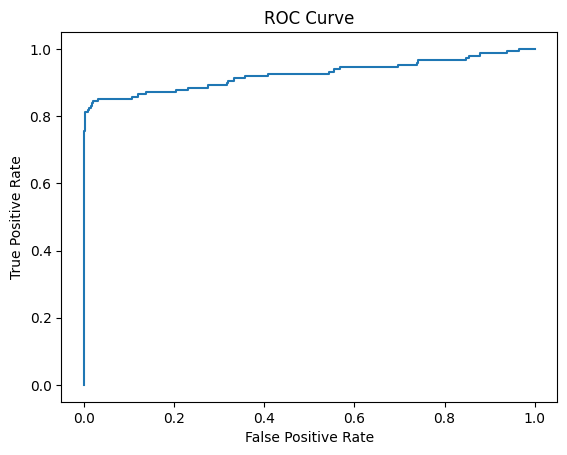

AUC: 0.9237577691414376


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_probs = model.predict_proba(x_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_probs)

plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

print("AUC:", roc_auc_score(y_test, y_probs))

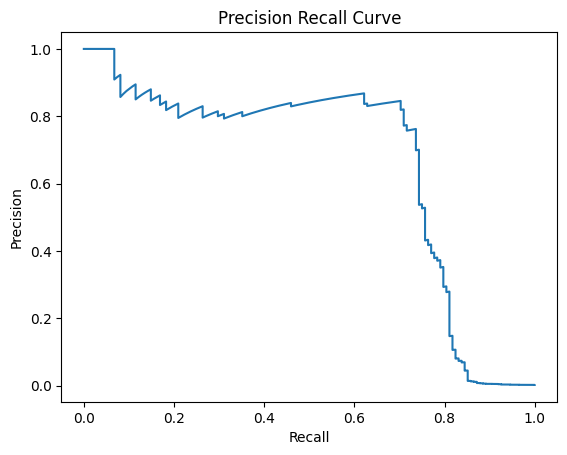

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_probs)

plt.plot(recall, precision)
plt.title("Precision Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

No começo o modelo é muito conservador e algumas fraudes podem passar despercebidas, comforme o Recall almenta essa precisão diminui, e conforme o recall almenta o modelo começa a classificar tudo como fraude

# Balanceamento de Dados

## Undersampling
O modelo aprende melhor a identificar fraudes, porém reduz a qualidade dos dados

In [ ]:
# Undersampling
fraudes = df[df["Class"] == 1]
normais = df[df["Class"] == 0].sample(len(fraudes), random_state=42)

df_under = pd.concat([fraudes, normais])

## Oversampling

Não perdemos dados e criamos a representação da classe fraude, por outro lado, estamos criando dados artificiais

In [ ]:
# Oversampling
from imblearn.over_sampling import SMOTE

smote = SMOTE()

x_res, y_res = smote.fit_resample(x, y)

## RandomForest

Modelo de arvores de decisões que vão aprendendo e ficando mais preciso

Estimamos 50 arvores e limitando até 10 para não ocorrer overfitting(o modelo decorar os dados)

class_weight = dando mais importancia para as classes fraudes e ajuda o modelo não ignorar as ocorrencias

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    class_weight="balanced",
    n_jobs=1,
    random_state=42
)

rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)

print(classification_report(y_test, y_pred_rf))

Agora o modelo consegue identificar mais fraudes comparado com a regressão logistica e o F1 também aumentou

# Pipeline

passam por uma padronização e depois pelo modelo em um unico fluxo

In [ ]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

pipeline.fit(x_train, y_train)

x_pred = pipeline.predict(x_test)

se a probabilidade do threshold for maior que 0.3 é considerado fraude, sendo mais rigoroso com as fraudes, aumentando o recall para detectar mais fraudes

In [ ]:
threshoud = 0.3

y_pred_custom = (y_probs > threshoud).astype(int)

print(classification_report(y_test, y_pred_custom))

# Modelo Avançado - XGBoost

é um dos algoritmos mais usados em competiçoes e mercado
ele é mais poderoso que o Random Forest para muitos problemas

boosting são varios modelos de arvore treinados em sequencia, um tentando corrigir o erro do outro, um aprendizado sequencial

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    scale_pos_weight=10, #ajuda com desbalanceamento
    use_label_encoder=False,
    eval_metric="logloss"
)

xgb.fit(x_train, y_train)
y_pred_xgb = xgb.predict(X_test)

NameError: name 'x_train' is not defined

In [ ]:
print(classification_report(y_test, y_pred_xgb))

# Importancia das variáveis

ajuda a entender quais variaveis influenciam mais o modelo.

In [ ]:
import matplotlib.pyplot as plt

importancias = xgb.feature_importances_

plt.bar(range(len(importancias)), importancias)
plt.title("Importância das variáveis")
plt.show()

NameError: name 'xgb' is not defined

No grafico podemos ver que o modelo utiliza algumas variáveis com muito mais importância que outras, e ela vai carregar um padrão muito forte na detecção de fraudes

# Ajuste de hiperparâmetros

Testamos várias combinações para melhorar o modelo.

In [ ]:
from sklearn.model_selection import  GridSearchCV

param_grid = {
    "max_depth" : [3, 5],
    "n_estimators" : [50, 100]
}

grid = GridSearchCV(
    XGBClassifier(eval_metric="logloss"),
    param_grid,
    scoring="recall",
    cv=3
)

grid.fit(X_train, y_train)

print("Melhor modelo:", grid.best_params_)

GridSearchCV é uma tecnica de fazer varias combinações de parâmetros e encontrar a melhor, o grid vai identificar qual é o melhor (recall), para melhorar nosso desempenho

# Explicabilidade (SHAP)

SHAP mostra como cada variável influencia a decisão do modelo

In [ ]:
explainer = shap.Explainer(xgb)
shap_values = explainer(X_test[:100])

shap.plots.bar(shap_values)

o shap vai explicar como cada variavel contribui para a compreensao do modelo, o impacto em cada previsão, podemos ver que a V4 e V14 tem mais impacto na tomada de decisão, conseguimos entender o modelo mesmo ele sendo complexo.
Ele é muito importante para confianca, auditoria, não basta só tomar decisões, precisamos entender o motivo do algoritmo tomar essa decisão